In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

import numpy as np
from matplotlib import pyplot as plt

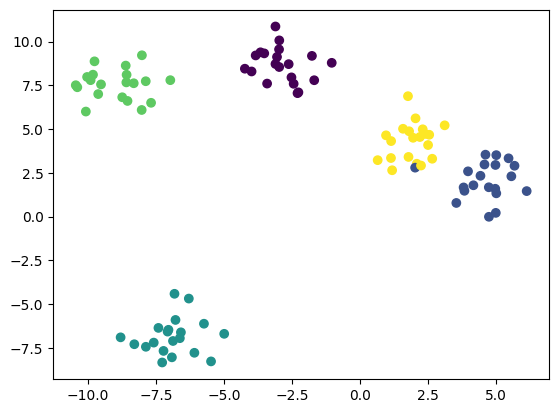

In [3]:
X, lbls = make_blobs(centers=5, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=lbls)


In [4]:
def divisive_clustering(X, max_depth=3, min_samples=5):

  if X.shape[0] <= min_samples or max_depth <= 0:

    return [X]

  kmeans = KMeans(n_clusters=2, random_state=42)
  kmeans.fit(X)

  labels = kmeans.labels_

  cluster_0 = X[labels == 0]
  cluster_1 = X[labels == 1]

  return divisive_clustering(cluster_0, max_depth-1, min_samples) + divisive_clustering(cluster_1, max_depth-1, min_samples)

In [5]:
clustering = divisive_clustering(X, max_depth=5, min_samples=5)

cls_lengths = [len(cls) for cls in clustering]

In [6]:
cls_centroids = [cls.mean(axis=0) for cls in clustering]

In [9]:
centroid_lengths = [[center[0], center[1], length] for center, length in zip(cls_centroids, cls_lengths)]
centroid_lengths = np.array(centroid_lengths)

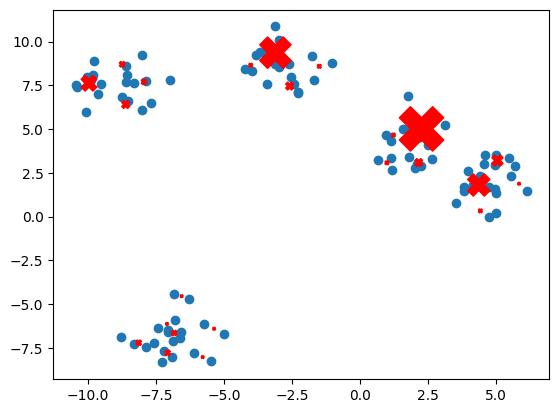

In [13]:
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroid_lengths[:, 0], centroid_lengths[:, 1], s=2**centroid_lengths[:, 2], marker="X", color="red")